In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [2]:

# Functions
def fit_and_evaluate_poly(X_train, y_train, X_test, y_test, degree):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = sm.OLS(y_train, X_train_poly).fit()
    y_pred = model.predict(X_test_poly)

    rss = np.sum((y_test - y_pred) ** 2)
    aic = model.aic
    bic = model.bic
    r2_adj = model.rsquared_adj

    return model, y_pred, rss, aic, bic, r2_adj
# Function to highlight maximum in red
def highlight_max_red(s):
    is_max = s == s.max()
    return ['color: red' if v else '' for v in is_max]

# Function to highlight minimum in red
def highlight_min_red(s):
    is_min = s == s.min()
    return ['color: red' if v else '' for v in is_min]

<div dir="rtl"> 

# רגרסיה פולינומית

## רגרסיה פולינומית מרחיבה את הרגרסיה הליניארית על ידי הוספת חזקות של המשתנה המסביר כמשתנים מסבירים נוספים. בדרך זו ניתן להתאים קשרים לא ליניאריים תוך שימוש במסגרת של מודל ליניארי.



<div dir="rtl"> 

## $$ f(x) = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3+ ...   $$

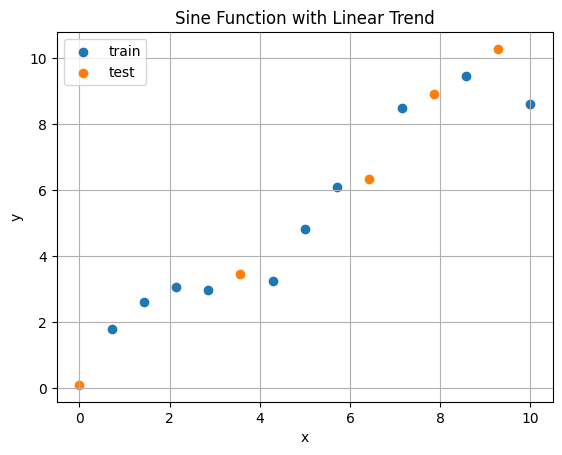

In [3]:
np.random.seed(0)
x = np.linspace(0, 10, 15)

# Define y as sine with linear trend
y = np.sin(x) + x + np.random.uniform(-1,1,15)

X = x.reshape(-1, 1)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Plot the function
plt.scatter(X_train, y_train, label = 'train')
plt.scatter(X_test, y_test, label = 'test')
plt.legend()
plt.title('Sine Function with Linear Trend')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

<div dir="rtl"> 

### תחילה ננסה לעשות רגרסיה פולינומית מסדר 2

### צריך לעשות הכנה עבור הפולינום כלומר $x^2$

In [4]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

X_train_poly.shape, X_test_poly.shape

((10, 3), (5, 3))

In [5]:
X_train

array([[ 5.71428571],
       [ 1.42857143],
       [ 0.71428571],
       [10.        ],
       [ 2.85714286],
       [ 5.        ],
       [ 7.14285714],
       [ 8.57142857],
       [ 2.14285714],
       [ 4.28571429]])

In [6]:
X_train_poly

array([[  1.        ,   5.71428571,  32.65306122],
       [  1.        ,   1.42857143,   2.04081633],
       [  1.        ,   0.71428571,   0.51020408],
       [  1.        ,  10.        , 100.        ],
       [  1.        ,   2.85714286,   8.16326531],
       [  1.        ,   5.        ,  25.        ],
       [  1.        ,   7.14285714,  51.02040816],
       [  1.        ,   8.57142857,  73.46938776],
       [  1.        ,   2.14285714,   4.59183673],
       [  1.        ,   4.28571429,  18.36734694]])

<div dir="rtl"> 

### נשים לב כי יש לנו 3 עמודות, עמודה של 1ים עבור החותך, עמודה של X ועמודה של $X^2$

### עכשיו נתאים את המודל 

In [7]:
model = sm.OLS(y_train, X_train_poly).fit()

<div dir="rtl"> 

## שימו לב שיש לנו כאן חלוקה לtrain ו test.

### במכונה לומדת מחלקים את הנתונים ל־Train ו־Test כדי להעריך את יכולת הכללה של המודל.
### ה־Train set משמש ללמידת הפרמטרים, ואילו ה־Test set בודק כיצד המודל מתפקד על נתונים שלא "ראה" במהלך האימון. כך נמנעים מהתאמת־יתר (Overfitting) ומקבלים הערכה אמינה לדיוק העתידי.

## כעת ננסה לחזות את הערכים האמיתיים עבור הtrain וה-test

In [8]:
X_train_poly

array([[  1.        ,   5.71428571,  32.65306122],
       [  1.        ,   1.42857143,   2.04081633],
       [  1.        ,   0.71428571,   0.51020408],
       [  1.        ,  10.        , 100.        ],
       [  1.        ,   2.85714286,   8.16326531],
       [  1.        ,   5.        ,  25.        ],
       [  1.        ,   7.14285714,  51.02040816],
       [  1.        ,   8.57142857,  73.46938776],
       [  1.        ,   2.14285714,   4.59183673],
       [  1.        ,   4.28571429,  18.36734694]])

In [9]:
y_pred_test = model.predict(X_test_poly)
y_pred_train = model.predict(X_train_poly)
y_pred_all = model.predict(poly.fit_transform(X))

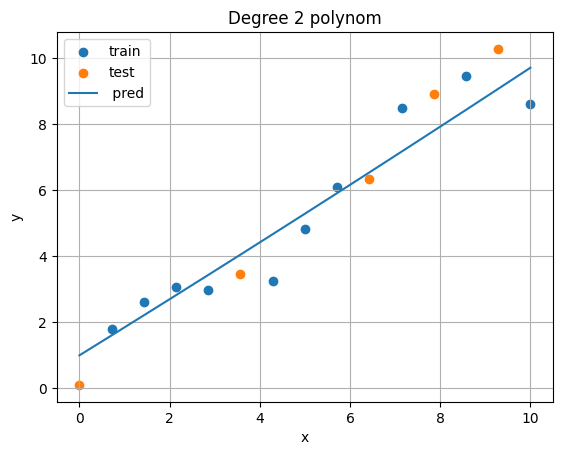

In [10]:
plt.scatter(X_train, y_train, label = 'train')
plt.scatter(X_test, y_test, label = 'test')
# plt.scatter(X_train, y_pred_train, label = 'train pred')
# plt.scatter(X_test, y_pred_test, label = 'test pred')
plt.plot(x, y_pred_all, label = ' pred')
plt.legend()
plt.title('Degree 2 polynom')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

<div dir="rtl"> 

### נראה שיש שגיאות גם בtrain וגם בtest.

### ננסה לראות האם ניתן לשפר את הדיוק על ידי הגדלת הסדר של הפולינום.

### ננסה עבור גדלים של 3 עד 10.

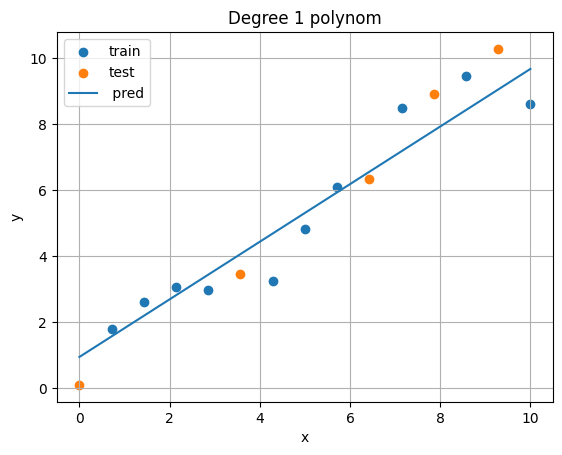

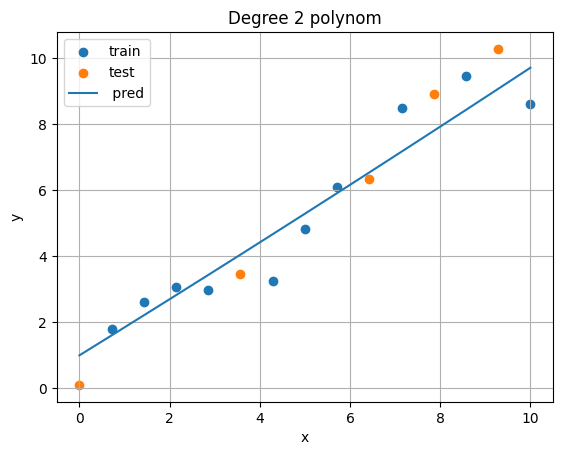

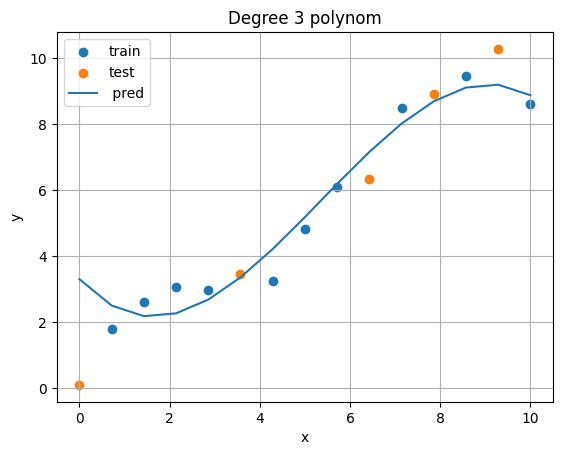

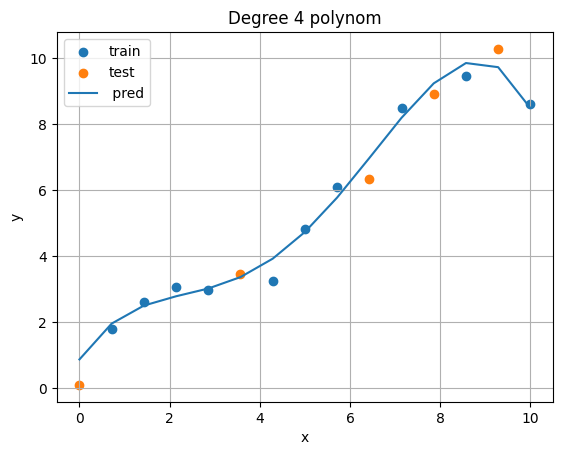

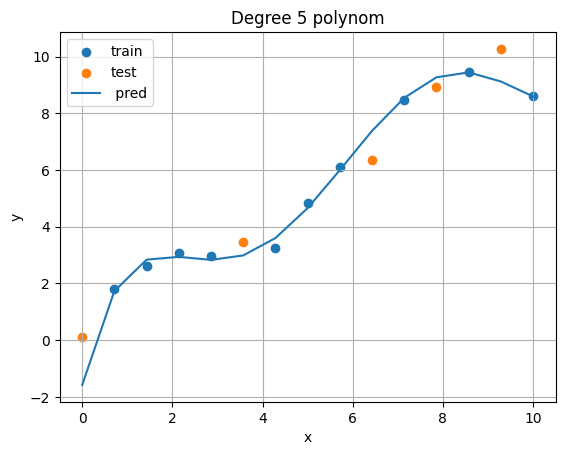

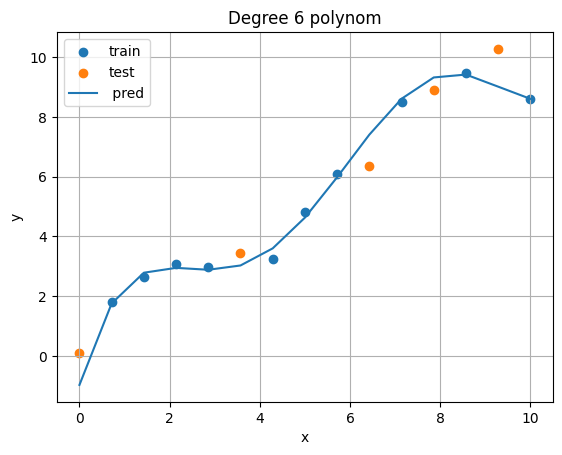

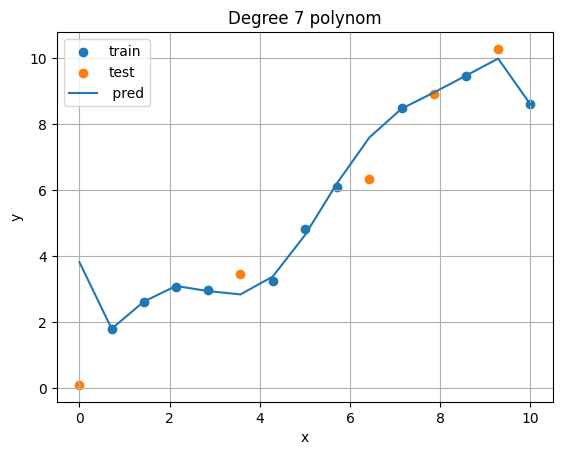

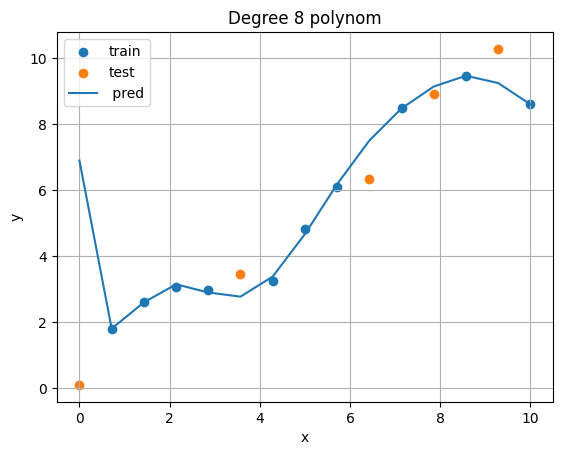

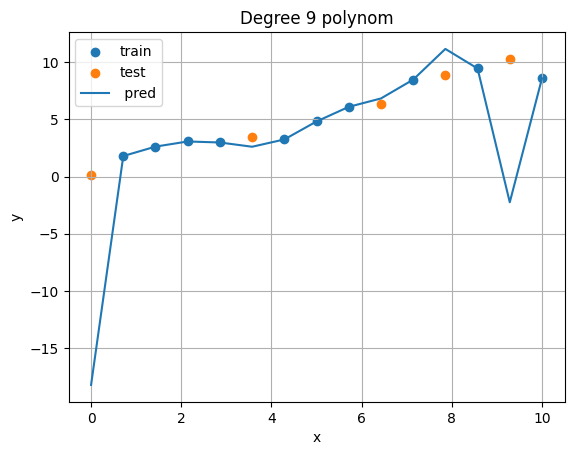

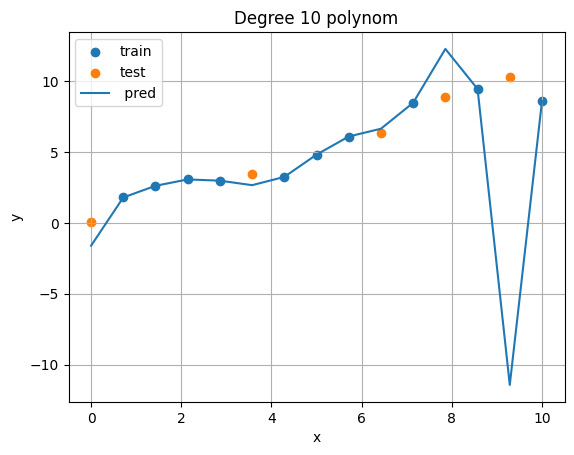

In [11]:
for deg in range(1,11):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    model = sm.OLS(y_train, X_train_poly).fit()
    y_pred_all = model.predict(poly.fit_transform(X))


    plt.scatter(X_train, y_train, label = 'train')
    plt.scatter(X_test, y_test, label = 'test')


    plt.plot(x, y_pred_all, label = ' pred')
    plt.legend()
    plt.title('Degree {} polynom' . format(deg))
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    

<div dir="rtl"> 


### נראה שככל שמתקדמים בסדר הפולינום ההאמה לtrain גדלה אבל זה אל המקרה עבור הtest.

### בעצם, זה מקרה קלאסי של overfitting.

### בנוסף נשים לב שיש לנו 10 נקודות והתאמה מסדר גדול 9 ומעלה היא מושלם. 

### זה לא במקרה, עבור n נקודות ניתן להעביר פולינום מסדר גודל של n-1.

### למשל, קו ישר שהוא פולינום מסדר גודל 1 ניתן להעביר קו ישר שעובר דרך כל שתי נקודות במרחב

## מה יהיה מדד טוב כדי לדעת האם המודל שלנו טוב?

## אפשר תחילה לחשב MSE של הנקודות שחזינו מול הנקודות האמתיות.



In [12]:
poly = PolynomialFeatures(degree=deg)
X_train_poly = poly.fit_transform(X_train)

In [13]:
df_sum = pd.DataFrame([])

for deg in range(1,11):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = sm.OLS(y_train, X_train_poly).fit()
    y_pred_test = model.predict(X_test_poly)
    y_pred_train = model.predict(X_train_poly)
    mse_test = ((y_pred_test - y_test[:,0])**2).mean()
    mse_train = ((y_pred_train - y_train[:,0])**2).mean()
    curr_ind = df_sum.shape[0]
    df_sum.loc[curr_ind, 'degree'] = deg
    df_sum.loc[curr_ind, 'MSE_test'] = mse_test
    df_sum.loc[curr_ind, 'MSE_train'] = mse_train
    df_sum.loc[curr_ind, '$R^2$'] = model.rsquared


df_sum.sort_values(by = 'MSE_test')

,degree,MSE_test,MSE_train,$R^2$
3,4.0,0.281423,9.427580e-02,0.987051
0,1.0,0.779605,6.764180e-01,0.907093
1,2.0,0.783947,6.759925e-01,0.907151
5,6.0,0.842481,2.461316e-02,0.996619
4,5.0,1.113640,2.579597e-02,0.996457
2,3.0,2.432195,2.916925e-01,0.959936
6,7.0,3.167820,6.873773e-03,0.999056
7,8.0,9.823851,6.154991e-03,0.999155
9,10.0,97.262774,4.097020e-12,1.000000
8,9.0,99.781040,3.094527e-12,1.000000


In [14]:
df_sum

,degree,MSE_test,MSE_train,$R^2$
0,1.0,0.779605,6.764180e-01,0.907093
1,2.0,0.783947,6.759925e-01,0.907151
2,3.0,2.432195,2.916925e-01,0.959936
3,4.0,0.281423,9.427580e-02,0.987051
4,5.0,1.113640,2.579597e-02,0.996457
5,6.0,0.842481,2.461316e-02,0.996619
6,7.0,3.167820,6.873773e-03,0.999056
7,8.0,9.823851,6.154991e-03,0.999155
8,9.0,99.781040,3.094527e-12,1.000000
9,10.0,97.262774,4.097020e-12,1.000000


<div dir="rtl"> 


## ה MSE הכי נמוך מתקבל כאשר משתמשים בפולינום מסדר 4. 

## אבל מה אם אני לא רוצה לחלק את הנתונים שלי לtrain וtest. כאשר אני עושה את זה אני מאבד נתונים חשובים. 

## איך אני איזה מדד להשתמש?

## נציע 3 מדדים: AIC, BIC, $R^2$ adjusted

## AIC: Akaike Information Criterion

<div dir="rtl"> 
  




### במקרה של רגרסיה ליניארית עם שגיאות נורמליות:

### $$ \text{AIC} = n \cdot \ln\left(\frac{\text{RSS}}{n}\right) + 2k $$

### - \( n \) — מספר התצפיות  
### - RSS  — סכום ריבועי השאריות  
### - \( k \) — מספר הפרמטרים (כולל הקבוע)

### RSS — סכום ריבועי השאריות:

### $$ RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $$

### כאשר:  
### - \( $y_i$ \) — הערך האמיתי של תצפית מספר \( i \)  
### - \( $\hat{y}_i$ \) — הערך החזוי על ידי המודל עבור תצפית מספר \( i \)  
### - \( n \) — מספר התצפיות הכולל

###  RSS מודד את סכום הטעויות בריבוע, כלומר עד כמה התחזיות של המודל חורגות מהתצפיות בפועל.



## Bayesian Information Criterion (BIC)

<div dir="rtl"> 


### **BIC**:  



###     עבור רגרסיה ליניארית:

### $$  \text{BIC} = n \cdot \ln\left(\frac{\text{RSS}}{n}\right) + k \cdot \ln(n) $$

### - מעניש מורכבות מודל בצורה חזקה יותר מ־AIC.


## $R^2$ Adjusted

<div dir="rtl"> 

### $$ R^2_{\text{adj}} = 1 - \left( \frac{(1 - R^2)(n - 1)}{n - k - 1} \right) $$
### כאשר:  
### - \( $R^2$ \) — מקדם ההסבר הרגיל  
### - \( n \) — מספר התצפיות  
### - \( k \) — מספר המשתנים המסבירים (ללא הקבוע)

### הגרסה המתוקננת מענישה על הוספת משתנים שלא משפרים את ההסבר.


<div dir="rtl"> 

## הרעיון במדדים האלה שיש להם trade-off בין שני חלקים. הראשון מתגמל התאמה טוב לנתונים ואילו השני קונס ככל שמשתמשים ביותר פרמטרים. 

### אין הכרעה ברורה באילו מן השלושה להשתמש. לרוב יגיעו לאותו מסקנה.

### בואו נראה את ערכם של המדדים האלו במודל שלנו כאשר אנחנו משתשמים בכל המדדים

In [15]:
for deg in range(1,11):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X)
    model = sm.OLS(y, X_train_poly).fit()
    
    y_pred_train = model.predict(X_train_poly)
    
    rss = ((y_pred_train - y[:,0])**2).sum()
    curr_ind = df_sum.shape[0]
    df_sum.loc[deg-1, 'degree'] = deg
    
    df_sum.loc[deg-1, 'aic'] = model.aic
    df_sum.loc[deg-1, 'bic'] = model.bic
    df_sum.loc[deg-1, '$R^2_{adj}$'] = model.rsquared_adj
    df_sum.loc[deg-1, '$R^2$'] = model.rsquared
    df_sum.loc[deg-1, 'rss'] = rss

df_sum

,degree,MSE_test,MSE_train,$R^2$,aic,bic,$R^2_{adj}$,rss
0,1.0,0.779605,6.764180e-01,0.934034,39.557656,40.973756,0.928960,9.399754
1,2.0,0.783947,6.759925e-01,0.934141,41.533299,43.657450,0.923165,9.384503
2,3.0,2.432195,2.916925e-01,0.945046,40.818077,43.650277,0.930058,7.830645
3,4.0,0.281423,9.427580e-02,0.988958,18.746542,22.286793,0.984541,1.573458
4,5.0,1.113640,2.579597e-02,0.989394,20.141967,24.390268,0.983502,1.511301
5,6.0,0.842481,2.461316e-02,0.989765,21.607816,26.564168,0.982089,1.458431
6,7.0,3.167820,6.873773e-03,0.991845,20.199830,25.864231,0.983690,1.162022
7,8.0,9.823851,6.154991e-03,0.992255,21.425704,27.798156,0.981929,1.103573
8,9.0,99.781040,3.094527e-12,0.992348,23.244629,30.325131,0.978575,1.090331
9,10.0,97.262774,4.097020e-12,0.993431,22.956552,30.745104,0.977008,0.936078


In [16]:
styled_df = df_sum.style.apply(highlight_max_red, subset=[ '$R^2_{adj}$','$R^2$']) \
                    .apply(highlight_min_red, subset=['aic', 'bic','rss', 'MSE_test', 'MSE_train'])

styled_df

,degree,MSE_test,MSE_train,$R^2$,aic,bic,$R^2_{adj}$,rss
0,1.000000,0.779605,0.676418,0.934034,39.557656,40.973756,0.928960,9.399754
1,2.000000,0.783947,0.675993,0.934141,41.533299,43.657450,0.923165,9.384503
2,3.000000,2.432195,0.291692,0.945046,40.818077,43.650277,0.930058,7.830645
3,4.000000,0.281423,0.094276,0.988958,18.746542,22.286793,0.984541,1.573458
4,5.000000,1.113640,0.025796,0.989394,20.141967,24.390268,0.983502,1.511301
5,6.000000,0.842481,0.024613,0.989765,21.607816,26.564168,0.982089,1.458431
6,7.000000,3.167820,0.006874,0.991845,20.199830,25.864231,0.983690,1.162022
7,8.000000,9.823851,0.006155,0.992255,21.425704,27.798156,0.981929,1.103573
8,9.000000,99.781040,0.000000,0.992348,23.244629,30.325131,0.978575,1.090331
9,10.000000,97.262774,0.000000,0.993431,22.956552,30.745104,0.977008,0.936078


<div dir="rtl"> 

### לפי הטבלה לעיל כל שלוש המדדים שקונסים פרמטאים נוספים הראו שהכי כדאי להשתמש בפולינום מדרגה 4.

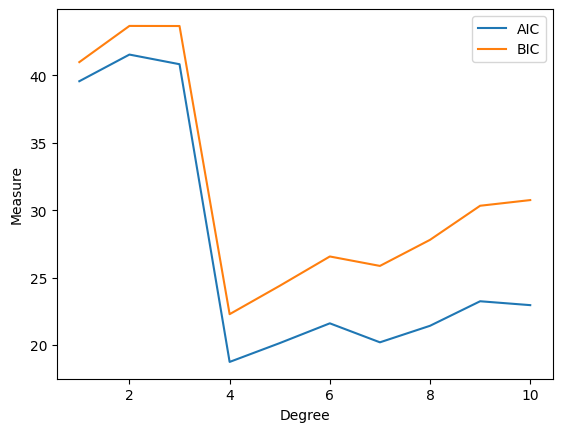

In [17]:
plt.figure()
plt.plot(df_sum['degree'], df_sum['aic'], label = 'AIC')
plt.plot(df_sum['degree'], df_sum['bic'], label = 'BIC')
plt.xlabel('Degree')
plt.ylabel('Measure')
plt.legend()
plt.show()

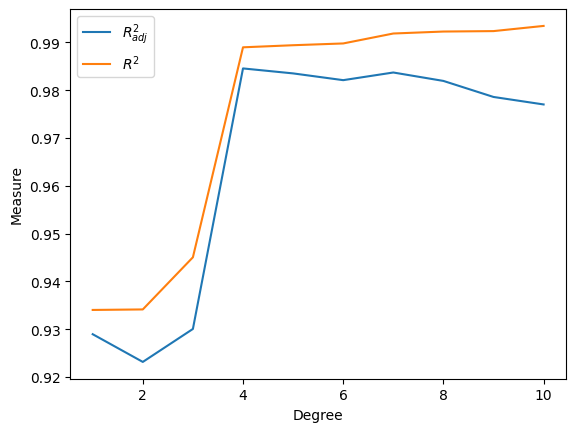

In [18]:
plt.figure()
plt.plot(df_sum['degree'], df_sum['$R^2_{adj}$'], label = '$R^2_{adj}$')
plt.plot(df_sum['degree'], df_sum['$R^2$'], label = '$R^2$')

plt.xlabel('Degree')
plt.ylabel('Measure')
plt.legend()
plt.show()